In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

# Plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries ready! ✅")

# Results manually define karo
results = {
    "CNN Classifier":    {"ROC_AUC": 0.9978, "Recall": 1.00, "F1": 0.16, "Precision": 0.09, "Type": "DL Supervised"},
    "Random Forest":     {"ROC_AUC": 0.9902, "Recall": 0.89, "F1": 0.44, "Precision": 0.29, "Type": "ML Supervised"},
    "LSTM Autoencoder":  {"ROC_AUC": 0.9822, "Recall": 0.93, "F1": 0.05, "Precision": 0.02, "Type": "DL Unsupervised"},
    "Isolation Forest":  {"ROC_AUC": 0.9559, "Recall": 0.04, "F1": 0.04, "Precision": 0.04, "Type": "ML Unsupervised"},
    "VAE":               {"ROC_AUC": 0.7700, "Recall": 0.16, "F1": 0.01, "Precision": 0.00, "Type": "Generative"},
    "GAN":               {"ROC_AUC": 0.2479, "Recall": 0.12, "F1": 0.01, "Precision": 0.00, "Type": "Generative"},
    "One-Class SVM":     {"ROC_AUC": 0.2388, "Recall": 0.01, "F1": 0.00, "Precision": 0.00, "Type": "ML Unsupervised"},
}

df_results = pd.DataFrame(results).T
df_results = df_results.sort_values('ROC_AUC', ascending=False)
print("\nAll Results:")
print(df_results)

Mounted at /content/drive
Libraries ready! ✅

All Results:
                 ROC_AUC Recall    F1 Precision             Type
CNN Classifier    0.9978    1.0  0.16      0.09    DL Supervised
Random Forest     0.9902   0.89  0.44      0.29    ML Supervised
LSTM Autoencoder  0.9822   0.93  0.05      0.02  DL Unsupervised
Isolation Forest  0.9559   0.04  0.04      0.04  ML Unsupervised
VAE                 0.77   0.16  0.01       0.0       Generative
GAN               0.2479   0.12  0.01       0.0       Generative
One-Class SVM     0.2388   0.01   0.0       0.0  ML Unsupervised


/tmp/ipykernel_1145/2364037007.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels([t.replace(' ', '\n') for t in type_names], fontsize=9)


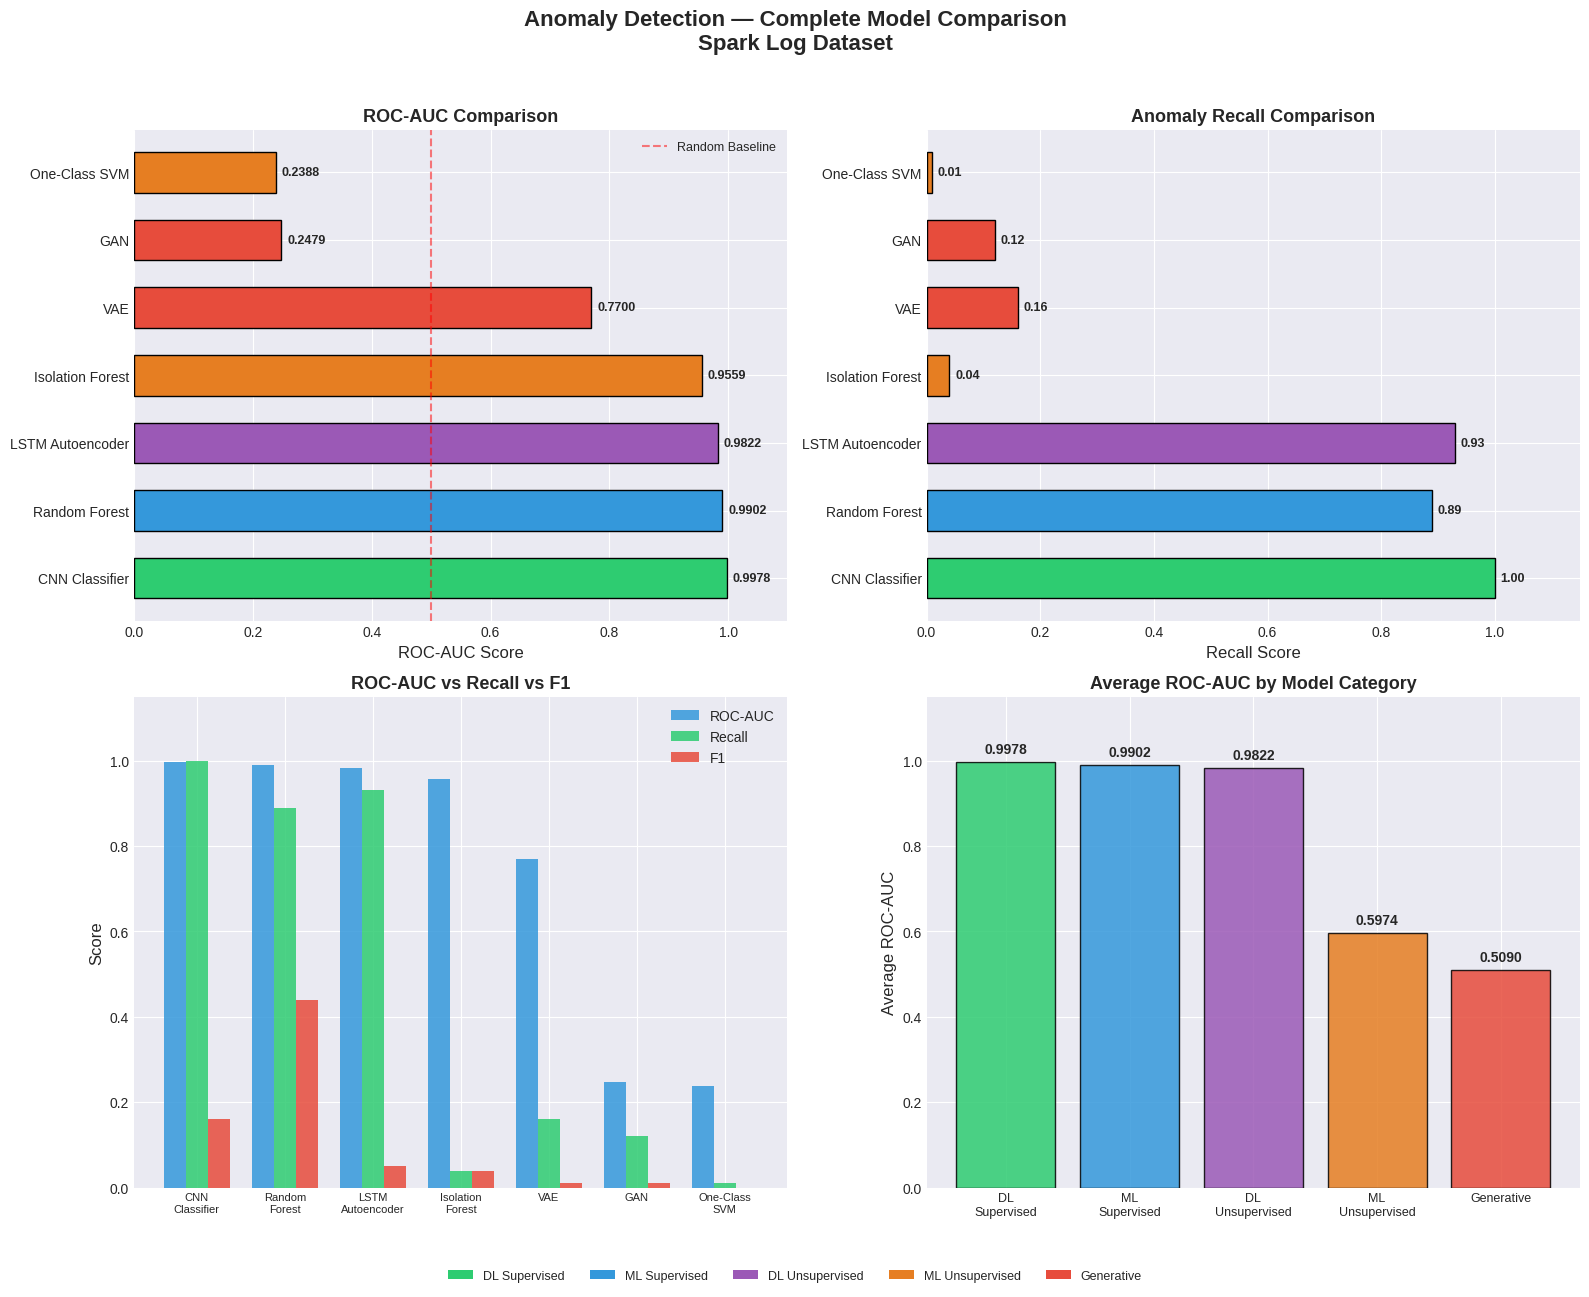

Plot saved! ✅


In [2]:
import matplotlib.pyplot as plt
import numpy as np

save_dir = "/content/drive/MyDrive/ASAD_Thesis/results"
os.makedirs(save_dir, exist_ok=True)

models = list(results.keys())
roc_values = [results[m]['ROC_AUC'] for m in models]
recall_values = [results[m]['Recall'] for m in models]
f1_values = [results[m]['F1'] for m in models]
precision_values = [results[m]['Precision'] for m in models]
types = [results[m]['Type'] for m in models]

# Color per type
color_map = {
    'DL Supervised':    '#2ecc71',
    'ML Supervised':    '#3498db',
    'DL Unsupervised':  '#9b59b6',
    'ML Unsupervised':  '#e67e22',
    'Generative':       '#e74c3c'
}
colors = [color_map[t] for t in types]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Anomaly Detection — Complete Model Comparison\nSpark Log Dataset",
             fontsize=16, fontweight='bold', y=1.02)

# ============================================
# Plot 1: ROC-AUC Bar Chart
# ============================================
ax1 = axes[0, 0]
bars = ax1.barh(models, roc_values, color=colors, edgecolor='black', height=0.6)
ax1.set_xlabel('ROC-AUC Score', fontsize=12)
ax1.set_title('ROC-AUC Comparison', fontsize=13, fontweight='bold')
ax1.set_xlim(0, 1.1)
ax1.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Random Baseline')

for bar, val in zip(bars, roc_values):
    ax1.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
ax1.legend(fontsize=9)

# ============================================
# Plot 2: Recall Comparison
# ============================================
ax2 = axes[0, 1]
bars2 = ax2.barh(models, recall_values, color=colors, edgecolor='black', height=0.6)
ax2.set_xlabel('Recall Score', fontsize=12)
ax2.set_title('Anomaly Recall Comparison', fontsize=13, fontweight='bold')
ax2.set_xlim(0, 1.15)

for bar, val in zip(bars2, recall_values):
    ax2.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=9, fontweight='bold')

# ============================================
# Plot 3: Multi-Metric Radar-style Bar
# ============================================
ax3 = axes[1, 0]
x = np.arange(len(models))
width = 0.25

ax3.bar(x - width, roc_values, width, label='ROC-AUC', color='#3498db', alpha=0.85)
ax3.bar(x, recall_values, width, label='Recall', color='#2ecc71', alpha=0.85)
ax3.bar(x + width, f1_values, width, label='F1', color='#e74c3c', alpha=0.85)

ax3.set_xticks(x)
ax3.set_xticklabels([m.replace(' ', '\n') for m in models], fontsize=8)
ax3.set_ylabel('Score', fontsize=12)
ax3.set_title('ROC-AUC vs Recall vs F1', fontsize=13, fontweight='bold')
ax3.legend(fontsize=10)
ax3.set_ylim(0, 1.15)

# ============================================
# Plot 4: Model Type Comparison (avg ROC-AUC)
# ============================================
ax4 = axes[1, 1]
type_groups = {}
for m, r in results.items():
    t = r['Type']
    type_groups.setdefault(t, []).append(r['ROC_AUC'])

type_names = list(type_groups.keys())
type_avgs = [np.mean(v) for v in type_groups.values()]
type_colors = [color_map[t] for t in type_names]

bars4 = ax4.bar(type_names, type_avgs, color=type_colors,
                edgecolor='black', alpha=0.85)
ax4.set_ylabel('Average ROC-AUC', fontsize=12)
ax4.set_title('Average ROC-AUC by Model Category', fontsize=13, fontweight='bold')
ax4.set_xticklabels([t.replace(' ', '\n') for t in type_names], fontsize=9)
ax4.set_ylim(0, 1.15)

for bar, val in zip(bars4, type_avgs):
    ax4.text(bar.get_x() + bar.get_width()/2, val + 0.02,
             f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

# Legend for colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[t], label=t) for t in color_map]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig(f"{save_dir}/complete_comparison.png", dpi=150,
            bbox_inches='tight')
plt.show()
print("Plot saved! ✅")

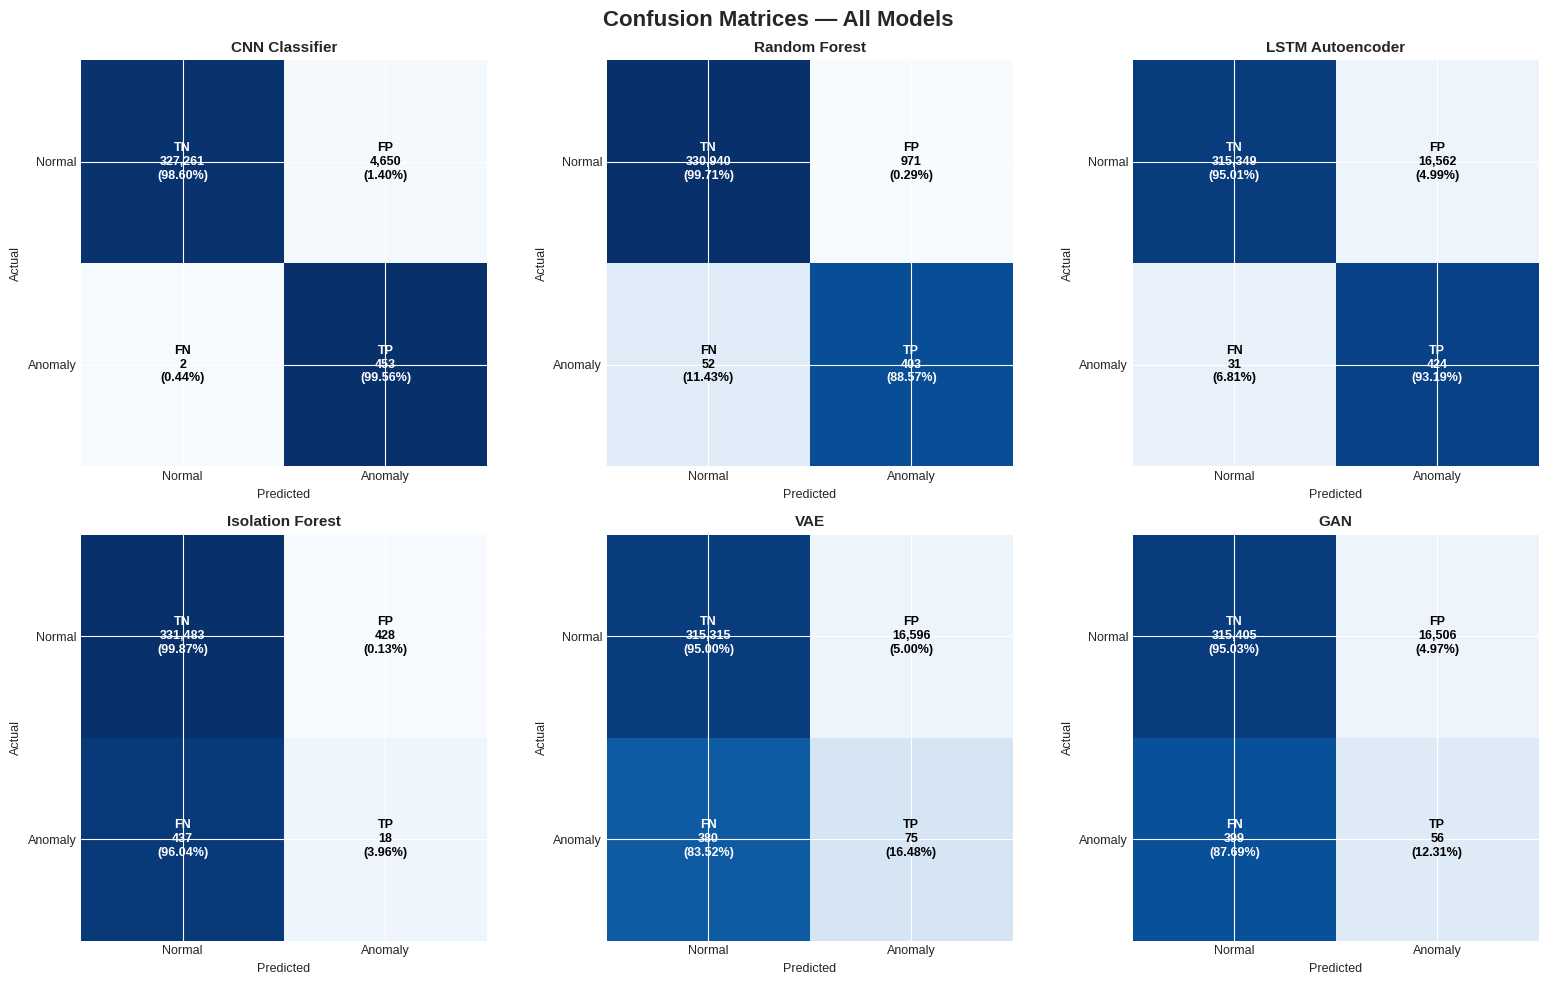

Confusion matrices saved! ✅


In [3]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Confusion Matrices — All Models",
             fontsize=16, fontweight='bold')

# Confusion matrices data
cms = {
    "CNN Classifier":   np.array([[327261, 4650], [2, 453]]),
    "Random Forest":    np.array([[330940, 971],  [52, 403]]),
    "LSTM Autoencoder": np.array([[315349, 16562],[31, 424]]),
    "Isolation Forest": np.array([[331483, 428],  [437, 18]]),
    "VAE":              np.array([[315315, 16596],[380, 75]]),
    "GAN":              np.array([[315405, 16506],[399, 56]]),
}

for ax, (model_name, cm) in zip(axes.flatten(), cms.items()):
    # Normalize
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    im = ax.imshow(cm_norm, interpolation='nearest',
                   cmap='Blues', vmin=0, vmax=1)
    ax.set_title(model_name, fontsize=11, fontweight='bold')

    # Values inside cells
    labels = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{labels[i][j]}\n{cm[i,j]:,}\n({cm_norm[i,j]:.2%})',
                   ha='center', va='center', fontsize=9,
                   color='white' if cm_norm[i,j] > 0.5 else 'black',
                   fontweight='bold')

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Normal', 'Anomaly'], fontsize=9)
    ax.set_yticklabels(['Normal', 'Anomaly'], fontsize=9)
    ax.set_ylabel('Actual', fontsize=9)
    ax.set_xlabel('Predicted', fontsize=9)

plt.tight_layout()
plt.savefig(f"{save_dir}/confusion_matrices.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrices saved! ✅")

Summary CSV saved! ✅
           Model        Category  ROC_AUC  Precision  Recall   F1  TP  FN    FP     TN
  CNN Classifier   DL Supervised   0.9978       0.09    1.00 0.16 453   2  4650 327261
   Random Forest   ML Supervised   0.9902       0.29    0.89 0.44 403  52   971 330940
LSTM Autoencoder DL Unsupervised   0.9822       0.02    0.93 0.05 424  31 16562 315349
Isolation Forest ML Unsupervised   0.9559       0.04    0.04 0.04  18 437   428 331483
             VAE      Generative   0.7700       0.00    0.16 0.01  75 380 16596 315315
             GAN      Generative   0.2479       0.00    0.12 0.01  56 399 16506 315405
   One-Class SVM ML Unsupervised   0.2388       0.00    0.01 0.00   5 450 16485 315426


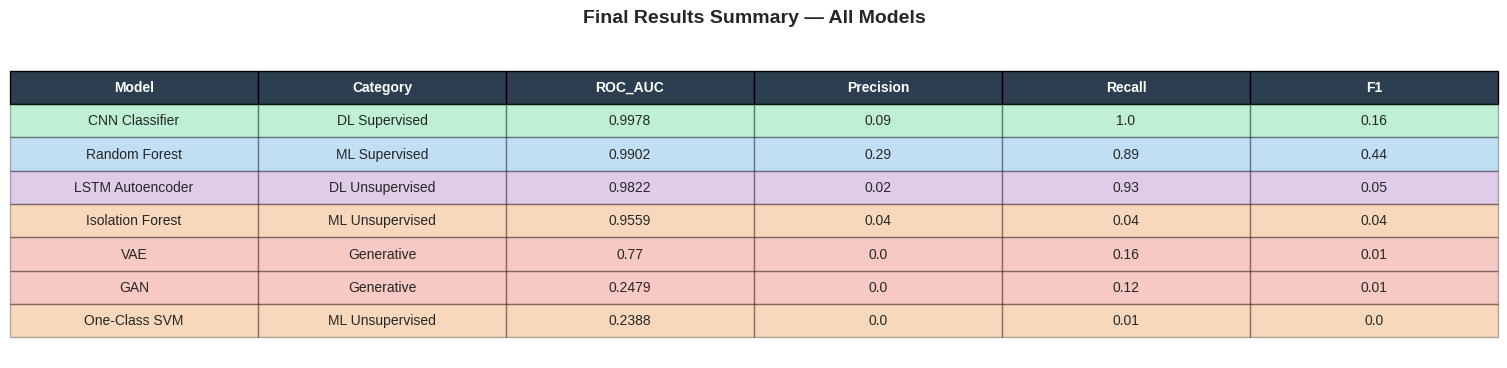

Summary table image saved! ✅


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import os

save_dir = "/content/drive/MyDrive/ASAD_Thesis/results"

# ============================================
# Summary Table
# ============================================
summary_data = {
    'Model':      ["CNN Classifier", "Random Forest", "LSTM Autoencoder",
                   "Isolation Forest", "VAE", "GAN", "One-Class SVM"],
    'Category':   ["DL Supervised", "ML Supervised", "DL Unsupervised",
                   "ML Unsupervised", "Generative", "Generative", "ML Unsupervised"],
    'ROC_AUC':    [0.9978, 0.9902, 0.9822, 0.9559, 0.7700, 0.2479, 0.2388],
    'Precision':  [0.09,   0.29,   0.02,   0.04,   0.00,   0.00,   0.00],
    'Recall':     [1.00,   0.89,   0.93,   0.04,   0.16,   0.12,   0.01],
    'F1':         [0.16,   0.44,   0.05,   0.04,   0.01,   0.01,   0.00],
    'TP':         [453,    403,    424,    18,     75,     56,     5],
    'FN':         [2,      52,     31,     437,    380,    399,    450],
    'FP':         [4650,   971,    16562,  428,    16596,  16506,  16485],
    'TN':         [327261, 330940, 315349, 331483, 315315, 315405, 315426],
}

df_summary = pd.DataFrame(summary_data)
df_summary = df_summary.sort_values('ROC_AUC', ascending=False)

# CSV save karo
df_summary.to_csv(f"{save_dir}/final_summary.csv", index=False)
print("Summary CSV saved! ✅")
print(df_summary.to_string(index=False))

# ============================================
# Summary Table as Image
# ============================================
fig, ax = plt.subplots(figsize=(16, 4))
ax.axis('off')

display_cols = ['Model', 'Category', 'ROC_AUC', 'Precision', 'Recall', 'F1']
table_data = df_summary[display_cols].values.tolist()
col_labels = display_cols

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2)

# Header color
for j in range(len(col_labels)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Row colors
row_colors = ['#2ecc71', '#3498db', '#9b59b6',
              '#e67e22', '#e74c3c', '#e74c3c', '#e67e22']
for i, color in enumerate(row_colors):
    for j in range(len(col_labels)):
        table[i+1, j].set_facecolor(color)
        table[i+1, j].set_alpha(0.3)

plt.title("Final Results Summary — All Models",
          fontsize=14, fontweight='bold', pad=20)
plt.savefig(f"{save_dir}/final_summary_table.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Summary table image saved! ✅")